In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import scipy.optimize as opt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.svm import SVC
from sklearn.metrics import jaccard_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import joblib
from sklearn.tree import DecisionTreeClassifier
import itertools

# بررسی دیتا 

In [36]:
clf = pd.read_csv("heart.csv")
clf.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [37]:
clf['output'].value_counts()

output
1    165
0    138
Name: count, dtype: int64

## تبدیل همه ی محتوای ستون ها یه عدد 

In [38]:
clf.dtypes

age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

In [39]:
clf['oldpeak'] = clf['oldpeak'].astype('int')
clf.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0,2,0,2,1


### جداسازی ویژگی های هدف

In [40]:
X = np.asarray(clf[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']])
X[0:5]

array([[ 63,   1,   3, 145, 233,   1,   0, 150,   0,   2,   0,   0,   1],
       [ 37,   1,   2, 130, 250,   0,   1, 187,   0,   3,   0,   0,   2],
       [ 41,   0,   1, 130, 204,   0,   0, 172,   0,   1,   2,   0,   2],
       [ 56,   1,   1, 120, 236,   0,   1, 178,   0,   0,   2,   0,   2],
       [ 57,   0,   0, 120, 354,   0,   1, 163,   1,   0,   2,   0,   2]])

In [41]:
y = np.asarray(clf['output'])
y[0:5]

array([1, 1, 1, 1, 1])

### تقسیم داده ها

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (242, 13) (242,)
Test set: (61, 13) (61,)


### نرمال سازی دیتا 

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

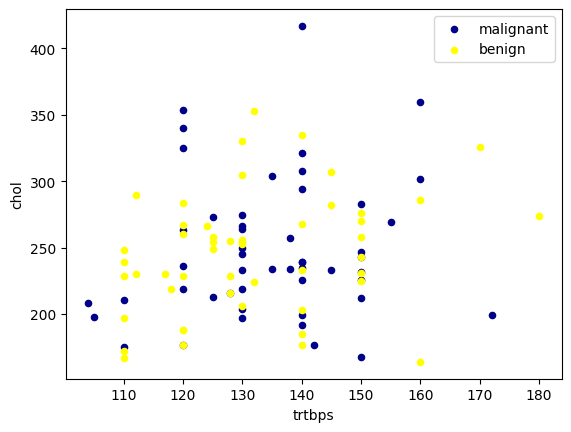

In [44]:
ax = clf[clf['output'] == 1][0:50].plot(kind='scatter', x='trtbps', y='chol', color='DarkBlue', label='malignant');
clf[clf['output'] == 0][0:50].plot(kind='scatter', x='trtbps', y='chol', color='Yellow', label='benign', ax=ax);
plt.show()

###  svm مدل 

In [45]:
from sklearn import svm
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train) 

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [46]:
yhat = clf.predict(X_test)
yhat [0:5] 

array([1, 0, 1, 1, 1])

In [47]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.89      0.92      0.90        36

    accuracy                           0.89        61
   macro avg       0.88      0.88      0.88        61
weighted avg       0.88      0.89      0.88        61

Confusion matrix, without normalization
[[21  4]
 [ 3 33]]


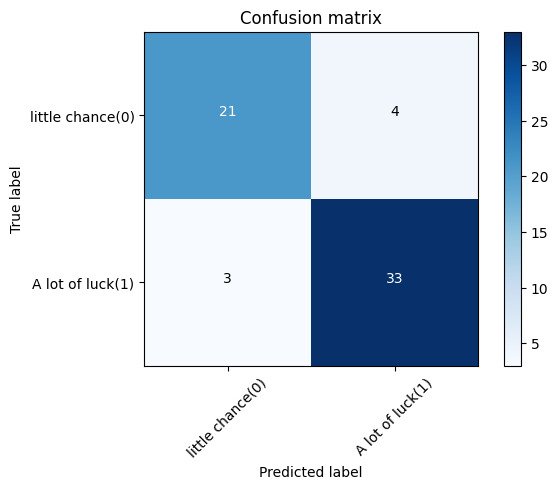

In [48]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[0,1])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['little chance(0)','A lot of luck(1)'],normalize= False,  title='Confusion matrix')

In [49]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted') 

0.8848609284270637

In [50]:
from sklearn.metrics import fbeta_score

# محاسبه F2
f2 = fbeta_score(y_test, yhat, beta=2)

print("F2-Score:", f2)


F2-Score: 0.9116022099447514


In [51]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.2, random_state=4)

In [52]:
scaler2 = StandardScaler()
X_train_scaled = scaler.fit_transform(X_trainset)
X_test_scaled = scaler.transform(X_testset)

### مدل درخت تصمیم

In [53]:
heartattackTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
heartattackTree

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
heartattackTree.fit(X_trainset,y_trainset)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
predTree = heartattackTree.predict(X_testset)

In [56]:
print (predTree [0:5])
print (y_testset [0:5])

[0 0 1 1 1]
[1 0 1 1 0]


In [57]:
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_testset, predTree))

DecisionTrees's Accuracy:  0.8524590163934426


In [58]:
f2 = fbeta_score(y_testset, predTree, beta=2)

print("F2-Score:", f2)

F2-Score: 0.9016393442622951


In [59]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_testset, predTree, labels=[1,0]))

[[33  3]
 [ 6 19]]


Confusion matrix, without normalization
[[33  3]
 [ 6 19]]


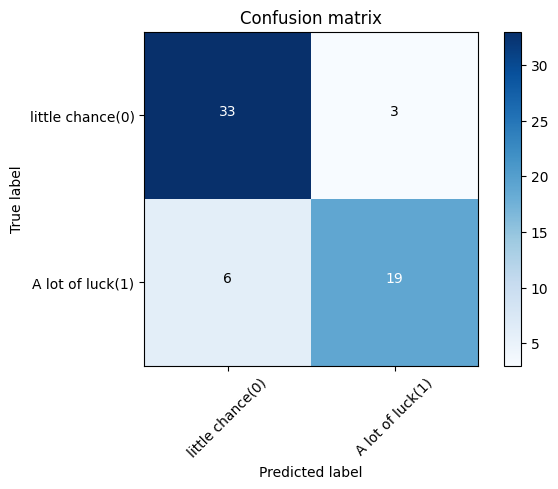

In [60]:
cnf_matrix = confusion_matrix(y_testset, predTree, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['little chance(0)','A lot of luck(1)'],normalize= False,  title='Confusion matrix')

## مدل لاجستیک رگرسیون

In [61]:
LR = LogisticRegression(C=0.01, solver='lbfgs',  max_iter=1000).fit(X_trainset,y_trainset)
LR

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
ypred = LR.predict(X_testset)
ypred

array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1])

In [63]:
ypred_prob = LR.predict_proba(X_testset)
ypred_prob

array([[0.27578294, 0.72421706],
       [0.67946436, 0.32053564],
       [0.36742529, 0.63257471],
       [0.13812319, 0.86187681],
       [0.42239994, 0.57760006],
       [0.46271825, 0.53728175],
       [0.50780291, 0.49219709],
       [0.12290658, 0.87709342],
       [0.30157948, 0.69842052],
       [0.18910571, 0.81089429],
       [0.22664484, 0.77335516],
       [0.11676901, 0.88323099],
       [0.43716035, 0.56283965],
       [0.42238386, 0.57761614],
       [0.47433997, 0.52566003],
       [0.85559052, 0.14440948],
       [0.30130261, 0.69869739],
       [0.21262025, 0.78737975],
       [0.49937473, 0.50062527],
       [0.33623783, 0.66376217],
       [0.16794671, 0.83205329],
       [0.28431078, 0.71568922],
       [0.80099481, 0.19900519],
       [0.40515785, 0.59484215],
       [0.35670781, 0.64329219],
       [0.74241372, 0.25758628],
       [0.69012131, 0.30987869],
       [0.276804  , 0.723196  ],
       [0.36665215, 0.63334785],
       [0.74722937, 0.25277063],
       [0.

In [64]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_testset, ypred, labels=[1,0]))

[[33  3]
 [ 9 16]]


Confusion matrix, without normalization
[[33  3]
 [ 9 16]]


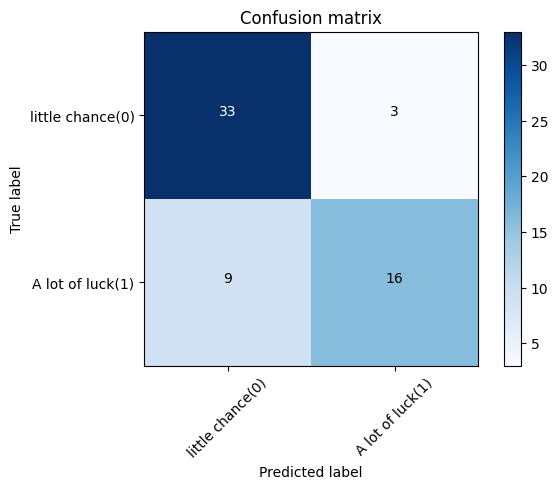

In [65]:
cnf_matrix = confusion_matrix(y_testset, ypred, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['little chance(0)','A lot of luck(1)'],normalize= False,  title='Confusion matrix')

In [66]:
print (classification_report(y_testset, ypred))

              precision    recall  f1-score   support

           0       0.84      0.64      0.73        25
           1       0.79      0.92      0.85        36

    accuracy                           0.80        61
   macro avg       0.81      0.78      0.79        61
weighted avg       0.81      0.80      0.80        61



In [67]:
from sklearn.metrics import log_loss
log_loss(y_testset, ypred_prob)

0.4361388553108052

In [68]:
f2 = fbeta_score(y_testset, ypred, beta=2)

print("F2-Score:", f2)

F2-Score: 0.8870967741935484


## conclusion

#### After evaluating three different models — Support Vector Machine (SVM), Logistic Regression, and Decision Tree — and comparing them based on F2-score and false negatives (FN), I conclude that the SVM model performs the best for predicting the likelihood of heart attack.